# My First AI Notebook

Exploring random data with NumPy.

**Goal:** keep the explanation, code, and results together.

In [1]:
import numpy as np

rng = np.random.default_rng(42)
data = rng.standard_normal(1000)

data.mean(), data.std()

(np.float64(-0.028891550995946837), np.float64(0.988722355396508))

In [2]:
%timeit rng.standard_normal(10000)

226 μs ± 17.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [3]:
%%time
samples = rng.standard_normal(1_000_000)
sample_mean = samples.mean()
print(f"Mean: {sample_mean:.4f}")

Mean: -0.0007
CPU times: user 51.5 ms, sys: 12.1 ms, total: 63.6 ms
Wall time: 48.7 ms


# Magic commands
- %env VARIABLE_NAME // READS ENV VARIABLE
- %matplotlib inline // Makes matplotlib plots
- %pip install package_name // Install packages


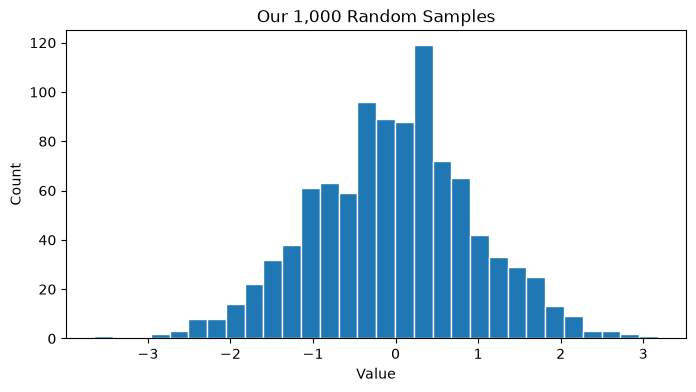

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, edgecolor="white")
plt.title("Our 1,000 Random Samples")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

In [5]:
from IPython.display import HTML, display

display(HTML(f"""
<table>
  <tr><th>Statistic</th><th>Value</th></tr>
  <tr><td>Sample count</td><td>{data.size}</td></tr>
  <tr><td>Mean</td><td>{data.mean():.4f}</td></tr>
  <tr><td>Standard deviation</td><td>{data.std():.4f}</td></tr>
</table>
"""))

Statistic,Value
Sample count,1000
Mean,-0.0289
Standard deviation,0.9887


In [6]:
import random

%timeit [random.random() for _ in range(100_000)]
%timeit rng.random(100_000)

9.81 ms ± 382 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
578 μs ± 24.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Comparing Model Results

Load recorded accuracy and training time from a CSV.
Compare accuracy first; then consider the training cost.

In [7]:
import csv
from pathlib import Path

csv_path = Path("lesson-05-results.csv")
with csv_path.open("w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["model", "accuracy", "training_seconds"])
    writer.writerows([
        ["Linear", 0.72, 0.1],
        ["Random Forest", 0.89, 2.3],
        ["Neural Net", 0.94, 45.6],
    ])

print(f"Created {csv_path.resolve()}")

Created /home/jbal271/AI_ENG/ai-engineering-from-scratch/lesson-05-results.csv


In [8]:
from html import escape

with csv_path.open(newline="") as file:
    results = list(csv.DictReader(file))

table_rows = "".join(
    f"<tr><td>{escape(row['model'])}</td>"
    f"<td>{float(row['accuracy']):.0%}</td>"
    f"<td>{float(row['training_seconds']):.1f}</td></tr>"
    for row in results
)
display(HTML(
    "<table><tr><th>Model</th><th>Accuracy</th>"
    "<th>Training seconds</th></tr>" + table_rows + "</table>"
))

Model,Accuracy,Training seconds
Linear,72%,0.1
Random Forest,89%,2.3
Neural Net,94%,45.6


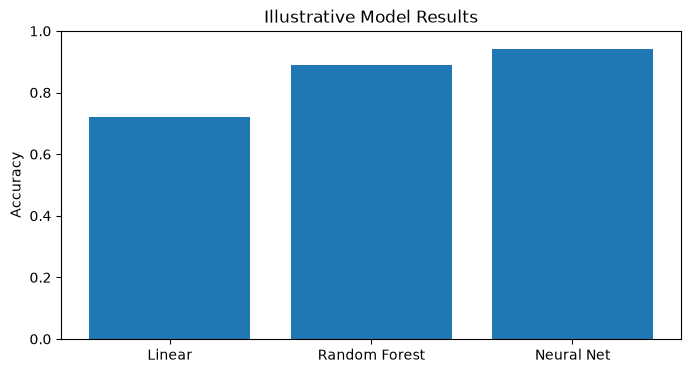

In [9]:
model_names = [row["model"] for row in results]
accuracies = [float(row["accuracy"]) for row in results]

plt.figure(figsize=(8, 4))
plt.bar(model_names, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Illustrative Model Results")
plt.show()
